## Testing for convergence of differential elastic cross sections with channel radius using realistic $NA$ interaction

In [1]:
import numpy as np
from IPython.display import Math, display
from periodictable import elements

In [2]:
from matplotlib import pyplot as plt

In [3]:
from tqdm import tqdm

import jitr

## set up system

In [4]:
A, Z = (208, 82)

In [5]:
name_core = str(elements[Z].symbol)
display(Math(f"^{{{A}}} \\rm{{{name_core}}}"))

<IPython.core.display.Math object>

In [6]:
neutron = (1, 0)
proton = (1, 1)
projectile = proton
target = (A, Z)

## Grab samples

In [7]:
# we have 416 samples from the KDUQ posterior
kduq_omp_samples = jitr.optical_potentials.kduq.get_samples(projectile)

## Set up solvers

In [8]:
lab_energy_grid = np.array([30, 60])

In [9]:
angles = np.linspace(0.01, np.pi, 120)

In [10]:
channel_radii = np.arange(10, 35, 2)
channel_radii

array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34])

In [11]:
reaction = jitr.reactions.Reaction(target=target, projectile=projectile, process="EL")

In [12]:
def set_up_grid(core, lab_energy_grid):
    solvers = []
    for _i, Elab in enumerate(lab_energy_grid):
        kinematics = reaction.kinematics(Elab)
        solvers.append([])
        for channel_radius in channel_radii:
            N = jitr.utils.suggested_basis_size(channel_radius * kinematics.k)
            lmax = int(max(30, kinematics.k * channel_radius))
            print(
                f"E={Elab:1.1f} MeV, ",
                f"R={channel_radius:1.1f} fm, ",
                f"{kinematics.k * channel_radius / (2 * np.pi):1.1f} λ's, ",
                f"nodes: {N}, ",
                f"max l: {lmax}",
            )
            solvers[-1].append(
                jitr.xs.elastic.DifferentialWorkspace.build_from_system(
                    reaction=reaction,
                    kinematics=kinematics,
                    angles=angles,
                    channel_radius_fm=channel_radius,
                    solver=jitr.rmatrix.Solver(N),
                    lmax=lmax,
                    smatrix_abs_tol=1e-6,
                )
            )
    return solvers

In [13]:
solvers = set_up_grid(target, lab_energy_grid)

E=30.0 MeV,  R=10.0 fm,  1.9 λ's,  nodes: 20,  max l: 30
E=30.0 MeV,  R=12.0 fm,  2.3 λ's,  nodes: 25,  max l: 30
E=30.0 MeV,  R=14.0 fm,  2.7 λ's,  nodes: 30,  max l: 30
E=30.0 MeV,  R=16.0 fm,  3.1 λ's,  nodes: 35,  max l: 30
E=30.0 MeV,  R=18.0 fm,  3.5 λ's,  nodes: 35,  max l: 30
E=30.0 MeV,  R=20.0 fm,  3.8 λ's,  nodes: 40,  max l: 30
E=30.0 MeV,  R=22.0 fm,  4.2 λ's,  nodes: 45,  max l: 30
E=30.0 MeV,  R=24.0 fm,  4.6 λ's,  nodes: 50,  max l: 30
E=30.0 MeV,  R=26.0 fm,  5.0 λ's,  nodes: 50,  max l: 31
E=30.0 MeV,  R=28.0 fm,  5.4 λ's,  nodes: 55,  max l: 33
E=30.0 MeV,  R=30.0 fm,  5.8 λ's,  nodes: 60,  max l: 36
E=30.0 MeV,  R=32.0 fm,  6.1 λ's,  nodes: 65,  max l: 38
E=30.0 MeV,  R=34.0 fm,  6.5 λ's,  nodes: 70,  max l: 41
E=60.0 MeV,  R=10.0 fm,  2.7 λ's,  nodes: 30,  max l: 30
E=60.0 MeV,  R=12.0 fm,  3.3 λ's,  nodes: 35,  max l: 30
E=60.0 MeV,  R=14.0 fm,  3.8 λ's,  nodes: 40,  max l: 30
E=60.0 MeV,  R=16.0 fm,  4.4 λ's,  nodes: 45,  max l: 30
E=60.0 MeV,  R=18.0 fm,  4.9 λ'

## Run calculations

In [14]:
N = 100  # number of samples to draw from each posterior
draws_kduq = np.random.choice(len(kduq_omp_samples), size=N)

In [15]:
xs = np.zeros((N, lab_energy_grid.size, channel_radii.size, angles.size))
for i, sample in enumerate(tqdm(kduq_omp_samples[draws_kduq, :])):
    for j, _Ecm in enumerate(lab_energy_grid):
        for k, _channel_radius in enumerate(channel_radii):
            solver = solvers[j][k]
            rgrid = solver.radial_grid()
            central_params, spin_orbit_params, coulomb_params = (
                jitr.optical_potentials.kduq.calculate_params(
                    projectile,
                    target,
                    solver.kinematics.Elab,
                    *sample,
                )
            )
            x = solver.xs(
                jitr.optical_potentials.kduq.central(rgrid, *central_params),
                jitr.optical_potentials.kduq.spin_orbit(rgrid, *spin_orbit_params),
                jitr.optical_potentials.kduq.coulomb_charged_sphere(
                    rgrid, *coulomb_params
                ),
            )
            if projectile == proton:
                x.dsdo /= solver.rutherford
            xs[i, j, k, :] = x.dsdo

100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [01:34<00:00,  1.06it/s]


In [16]:
benchmark = xs[:, :, -1:, :]
tests = xs[:, :, :-1, :]

diff = np.median(tests - benchmark, axis=0)
rel_diff = np.median((tests - benchmark) / benchmark, axis=0)
log_abs_diff = np.median(np.log(np.abs(tests - benchmark)), axis=0)
xs_median = np.median(xs, axis=0)

## Visualize results

In [17]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [18]:
Eidx = 1
print(f"Plots for E = {lab_energy_grid[Eidx]} MeV")

Plots for E = 60 MeV


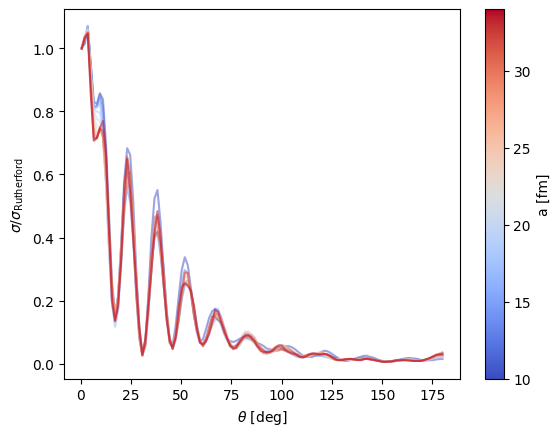

In [19]:
cmap = plt.get_cmap("coolwarm")
norm = mcolors.Normalize(vmin=min(channel_radii), vmax=max(channel_radii))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

for i in range(len(channel_radii)):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    plt.plot(angles * 180 / np.pi, xs_median[Eidx, i, :], color=color, alpha=0.5)
plt.gcf().colorbar(sm, ax=plt.gca(), label="a [fm]")
plt.xlabel(r"$\theta$ [deg]")


if projectile == neutron:
    plt.yscale("log")
    plt.ylabel(r"$\frac{d\sigma}{d\Omega}$ [mb/Sr]")
else:
    plt.ylabel(r"$\sigma / \sigma_{\text{Rutherford}}$")

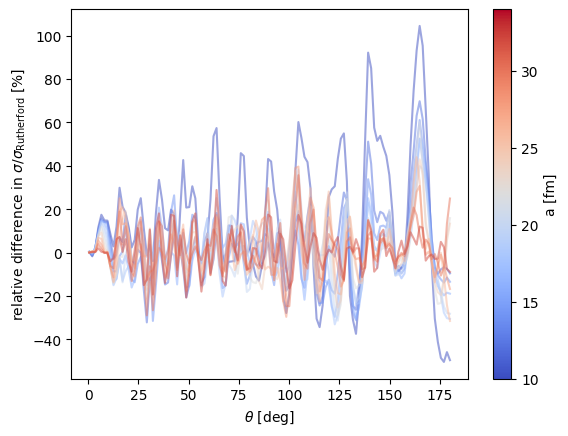

In [20]:
for i in range(len(channel_radii) - 1):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    plt.plot(angles * 180 / np.pi, rel_diff[Eidx, i, :] * 100, color=color, alpha=0.5)
plt.gcf().colorbar(sm, ax=plt.gca(), label="a [fm]")
plt.xlabel(r"$\theta$ [deg]")
if projectile == neutron:
    plt.ylabel(r"relative difference in $\frac{d\sigma}{d\Omega}$ [%]")
else:
    plt.ylabel(r"relative difference in $\sigma / \sigma_{\text{Rutherford}}$ [%]")

Text(0, 0.5, 'log absolute difference in $\\frac{d\\sigma}{d\\Omega}$')

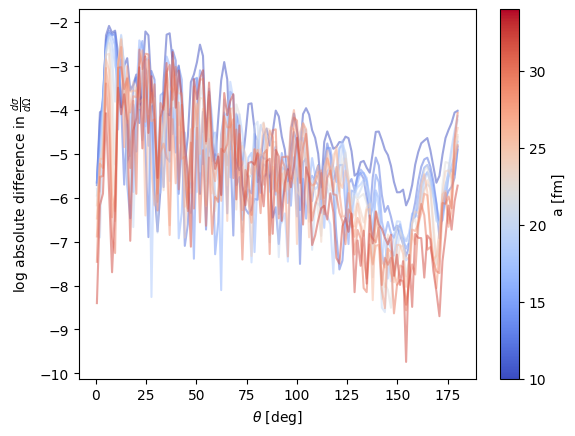

In [21]:
for i in range(len(channel_radii) - 1):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    plt.plot(angles * 180 / np.pi, log_abs_diff[Eidx, i, :], color=color, alpha=0.5)
plt.gcf().colorbar(sm, ax=plt.gca(), label="a [fm]")
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"log absolute difference in $\frac{d\sigma}{d\Omega}$")

Text(0, 0.5, 'log abs diff')

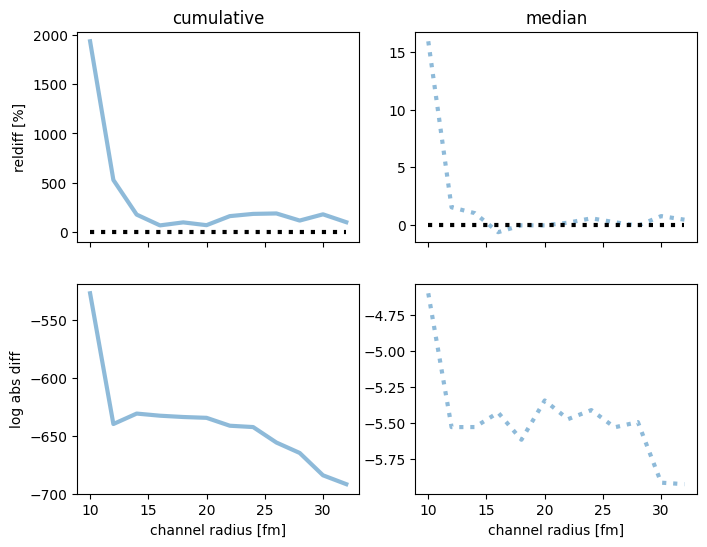

In [22]:
cum_diff = np.sum(diff[Eidx, ...], axis=-1)
cum_rel_diff = np.sum(rel_diff[Eidx, ...] * 100, axis=-1)
cum_log_abs_diff = np.sum(log_abs_diff[Eidx, ...], axis=-1)
med_diff = np.median(diff[Eidx, ...], axis=-1)
med_rel_diff = np.median(rel_diff[Eidx, ...] * 100, axis=-1)
med_log_abs_diff = np.median(log_abs_diff[Eidx, ...], axis=-1)

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(8, 6))
axes[0, 0].plot(
    channel_radii[:-1],
    cum_rel_diff,
    alpha=0.5,
    linewidth=3,
)
axes[0, 1].plot(
    channel_radii[:-1],
    med_rel_diff,
    ":",
    alpha=0.5,
    linewidth=3,
)
axes[0, 0].plot(
    channel_radii[:-1],
    np.zeros_like(channel_radii[:-1]),
    "k:",
    linewidth=3,
)
axes[0, 1].plot(
    channel_radii[:-1],
    np.zeros_like(channel_radii[:-1]),
    "k:",
    linewidth=3,
)
axes[1, 0].plot(
    channel_radii[:-1],
    cum_log_abs_diff,
    alpha=0.5,
    linewidth=3,
)
axes[1, 1].plot(
    channel_radii[:-1],
    med_log_abs_diff,
    ":",
    alpha=0.5,
    linewidth=3,
)
axes[-1, 0].set_xlabel("channel radius [fm]")
axes[-1, 1].set_xlabel("channel radius [fm]")
axes[0, 0].set_title("cumulative")
axes[0, 1].set_title("median")

axes[0, 0].set_ylabel("reldiff [%]")
axes[1, 0].set_ylabel("log abs diff")